In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the Dataset
df = pd.read_csv("../data/processed/ltv_dataset.csv")
df.head()

#Check the structure:

df.shape

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7032 non-null   str    
 1   gender           7032 non-null   str    
 2   SeniorCitizen    7032 non-null   int64  
 3   Partner          7032 non-null   str    
 4   Dependents       7032 non-null   str    
 5   tenure           7032 non-null   int64  
 6   PhoneService     7032 non-null   str    
 7   InternetService  7032 non-null   str    
 8   Contract         7032 non-null   str    
 9   MonthlyCharges   7032 non-null   float64
 10  TotalCharges     7032 non-null   float64
 11  Churn            7032 non-null   str    
 12  LTV              7032 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 714.3 KB


In [3]:
#Define Features and Target

#Target variable:

target = "LTV"

#Create X and y:

X = df.drop(columns=["LTV"])
y = df["LTV"]

#Drop customer ID because it is not a predictive feature:

X = X.drop(columns=["customerID"])

In [4]:
#Create Train-Test Split

#Use the same split as Day 7 so evaluation stays consistent.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
#Load the Trained Linear Regression Model

#If you saved the model on Day 7:

model = joblib.load("../models/linear_regression_ltv.pkl")
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'Churn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 

In [6]:
#Generate Predictions on Test Data
y_pred = model.predict(X_test)

#Preview predictions:

y_pred[:10]

array([1510.4299862 ,  462.90437142, 1366.06194328, 2032.04471906,
        155.85706993,   85.88786215, 4078.38300824, 1409.95451242,
       1804.33669671, 5532.02468907])

In [7]:
#Calculate MAE
#MAE = Mean Absolute Error

#This tells you the average absolute difference between actual LTV and predicted LTV.

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 47.709834521423645


In [8]:
#Calculate MSE
#MSE = Mean Squared Error

#This penalizes larger errors more heavily because errors are squared.

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 4812.110468169267


In [9]:
#Calculate RMSE
#RMSE = Root Mean Squared Error

#This brings MSE back to the original LTV unit scale.

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 69.36937702019002


In [10]:
#Calculate R² Score
#R² Score

#This tells you how much variance in LTV is explained by the model.

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9990688925041158


In [11]:
#Create a Summary Metrics Table

#This is a very good thing to include in your notebook.

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics_df

,Metric,Value
0,MAE,47.709835
1,MSE,4812.110468
2,RMSE,69.369377
3,R2 Score,0.999069


In [12]:
#Compare Actual vs Predicted Values

#Create a results table:

results = pd.DataFrame({
    "Actual_LTV": y_test.values,
    "Predicted_LTV": y_pred
})

results.head(10)

,Actual_LTV,Predicted_LTV
0,1525.00,1510.429986
1,469.30,462.904371
2,1329.25,1366.061943
3,2036.85,2032.044719
4,176.70,155.857070
5,89.40,85.887862
6,4204.20,4078.383008
7,1372.50,1409.954512
8,1807.00,1804.336697
9,5626.50,5532.024689


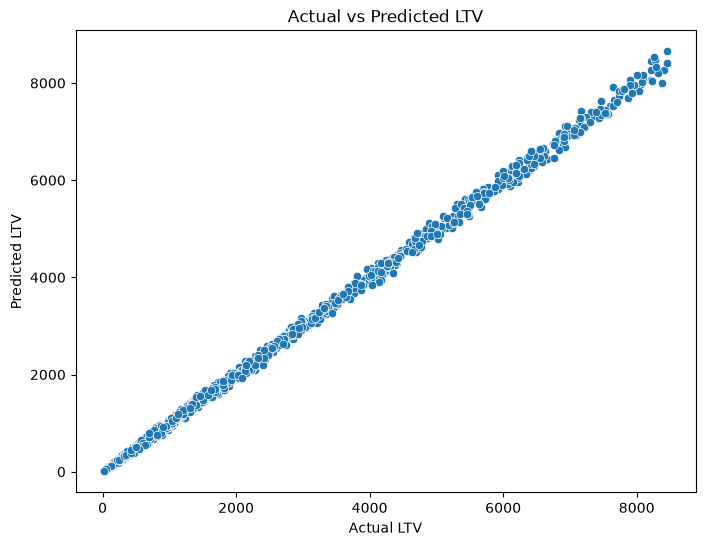

In [13]:
#Plot Actual vs Predicted Values

#This is the most important regression evaluation plot.

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV")
plt.show()

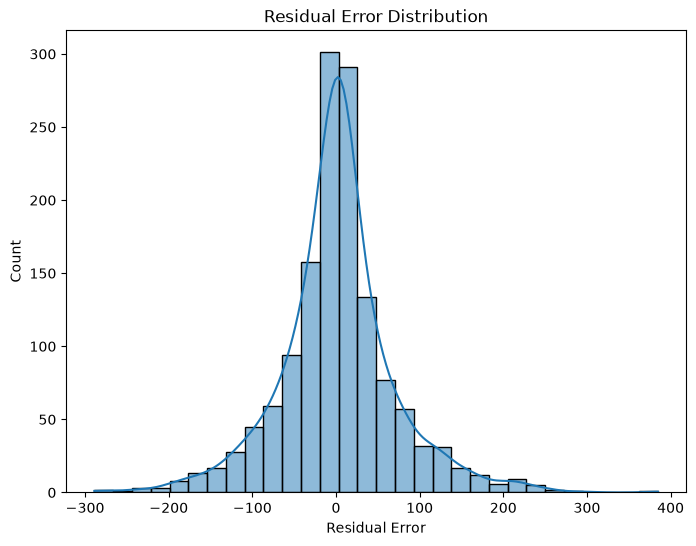

In [14]:
#Plot Residual Distribution

#Residual = Actual − Predicted

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Error Distribution")
plt.xlabel("Residual Error")
plt.show()